# 13. Spatio-Temporal Kriging 



**Dataset:** California PM2.5 monitoring network, 2025 (`data/CA_pm25_2025.csv`)  

**Target:** Monthly mean PM2.5 (µg/m³)  

**Library:** `pygstat` v0.1.0 — `STKriging`, `empirical_st_variogram`, `fit_metric_st_variogram`  

***



## Table of Contents

1. [Overview](#1-overview)
2. [What is Spatio-Temporal Kriging?](#2-what-is-spatio-temporal-kriging)
3. [How Space-Time Kriging Works](#3-how-space-time-kriging-works)
4. [Python Setup](#4-python-setup)
5. [Load and Explore the California PM2.5 Panel](#5-load-and-explore-the-california-pm25-panel)
6. [Hold-Out Station Split](#6-hold-out-station-split)
7. [Empirical Space-Time Variogram](#7-empirical-space-time-variogram)
8. [Fit the Metric ST Model](#8-fit-the-metric-st-model)
9. [Fit STKriging](#9-fit-stkriging)
10. [Validate on Held-Out Stations](#10-validate-on-held-out-stations)
11. [Leave-One-Out Check](#11-leave-one-out-check)
12. [Forecast One Month Ahead](#12-forecast-one-month-ahead)
13. [Map PM2.5 on a California Grid](#13-map-pm25-on-a-california-grid)
14. [CPU vs GPU ST Kriging Timing](#14-cpu-vs-gpu-st-kriging-timing)
15. [Summary and Conclusions](#15-summary-and-conclusions)
16. [Resources](#16-resources)



***
## 1. Overview

**Spatio-temporal ordinary kriging** extends ordinary kriging from a map to a
monitoring *network through time*. Each observation is a triple
$(\mathbf{u}_i, t_i, Z(\mathbf{u}_i, t_i))$ — a station location, a time stamp,
and a continuous measurement. The estimator is still a Best Linear Unbiased
Estimator (BLUE) of $Z(\mathbf{u}_0, t_0)$, but the covariance now depends on
**both** a spatial lag and a temporal lag.

This is the everyday setting of an environmental monitoring network (air quality,
groundwater, weather): sites are fixed, time is repeated, and a few stations
may miss a month. It is **not** the same as this library's Poisson
space-time kriging (`STPoissonKriging`), which is for *areal rates* that need
a population-reliability correction. PM2.5 here is a directly measured
concentration.

| Step | What we do |
|------|------------|
| Data | Load daily CA PM2.5 for 2025 (163 stations); aggregate to monthly means; project to California Albers (EPSG:3310, meters) |
| Split | Hold out **25 complete stations** entirely (~15%); train on the remaining 138 (including 7 with partial-year coverage) |
| Variogram | Estimate the empirical space-time semivariogram on complete training stations; fit a **metric** ST model |
| ST kriging | Fit `STKriging` on all training station-months; predict with a local neighborhood (`nmax=20`) |
| Validation | Predict every held-out station-month; report RMSE, MAE, $R^2$ vs a naive-mean baseline |
| Forecast | Predict month index 12 (one month past December 2025) at a few training sites |
| Mapping | Predict PM2.5 and kriging standard error on a 5 km grid covering California, all 12 months |
| CPU / GPU | Time k-NN `STKriging.predict` on CPU vs GPU using **sgsim** CA-like PM2.5 ($n=8{,}400$) |

By the end you will have a validated space-time interpolator, a monthly
PM2.5 surface for California in 2025, and a CPU vs GPU timing of local ST
kriging on an SGS-simulated dense panel.



***
## 2. What is Spatio-Temporal Kriging?

Ordinary kriging estimates a continuous variable $Z$ at an unobserved location
as a weighted linear combination of $N$ nearby observations,

$$
\hat Z(\mathbf u_0) = \sum_{i=1}^N \lambda_i\, Z(\mathbf u_i), \qquad
\sum_{i=1}^N \lambda_i = 1.
$$

The sum-to-one constraint makes the estimator unbiased when the mean of $Z$ is
unknown. The weights minimize estimation variance subject to that constraint.

A monitoring network reports $Z(\mathbf u_i, t_i)$: the same quantity at a set of
fixed stations, repeated over time. The estimator and the unbiasedness
constraint are unchanged. What changes is the covariance: $C$ must be a
function of **both** a spatial lag $h_s=\lVert\mathbf u_i-\mathbf u_j\rVert$
and a temporal lag $h_t=|t_i-t_j|$,

$$
\hat Z(\mathbf u_0,t_0) = \sum_{i=1}^N \lambda_i\, Z(\mathbf u_i,t_i),
\qquad \sum_{i=1}^N \lambda_i = 1.
$$

`pygstat.STKriging` is a thin wrapper around `pygstat.krige_st.krige_st` (a
Python port of gstat's `krigeST`; Pebesma, 2012). It stores the training
space-time observations and exposes `.predict()` / `.predict_id()` without
requiring a complete site $\times$ time grid — unlike empirical variogram
*estimation*, which does need one.

**When to use it**

- You have a continuous variable observed at points, repeatedly in time
- You want to interpolate at unsampled locations *and/or* unsampled times
- Stations need not share the exact same time stamps (an irregular panel is fine for kriging)

**When not to use it**

- Count / rate data over polygons with unequal population — use `STPoissonKriging`
- A purely spatial snapshot with no time dimension — use ordinary or simple kriging
- A strong, known trend in space or time that should be modeled explicitly — consider universal or regression kriging in space-time



***
## 3. How Space-Time Kriging Works

### 3.1 The kriging system

The weights $\lambda_i$ and a Lagrange multiplier $\mu$ solve

$$
\begin{bmatrix} \mathbf V & \mathbf 1 \\ \mathbf 1^\top & 0 \end{bmatrix}
\begin{bmatrix} \boldsymbol\lambda \\ \mu \end{bmatrix}
= \begin{bmatrix} \mathbf v_0 \\ 1 \end{bmatrix},
\qquad
\sigma^2 = C(0) - \boldsymbol\lambda^\top\mathbf v_0 - \mu,
$$

where $V_{ij}=C\big((\mathbf u_i,t_i)-(\mathbf u_j,t_j)\big)$ and
$v_{0,i}=C\big((\mathbf u_i,t_i)-(\mathbf u_0,t_0)\big)$. Covariance and
semivariogram are related by $C(h)=C(0)-\gamma(h)$.

### 3.2 The metric space-time model

This tutorial uses the **metric** model (Pebesma, 2012): space and time are
folded into one joint (anisotropic) distance

$$
h_{st} = \sqrt{h_s^2 + (a\,h_t)^2},
$$

where $a$ (`stAni`, meters per month here) makes space and time commensurable,
and a single ordinary variogram $\gamma(h_{st})$ is fit to it. It is the
simplest space-time model and a robust default when you do not have a strong
prior for separate spatial and temporal structure.

`pygstat.st_variogram_models` also implements `separable`, `productSum`, and
`sumMetric` models for cases with distinct spatial/temporal structure.

### 3.3 Empirical semivariogram

The empirical semivariogram is the Matheron estimator, binned jointly by
spatial and temporal lag:

$$
\hat\gamma(h_s,h_t) = \frac{1}{2\,|N(h_s,h_t)|}
   \sum_{(i,a),(j,b)\,\in\,N(h_s,h_t)} \big(Z(\mathbf u_i,t_a)-Z(\mathbf u_j,t_b)\big)^2,
$$

where $N(h_s,h_t)$ collects station-month pairs whose spatial distance falls in
the $h_s$ bin and whose time difference equals $h_t$.
`empirical_st_variogram` needs a *complete* station $\times$ month matrix
(every station observed every month). A handful of incomplete stations are
dropped for this step only; they are still used as kriging neighbors.

### 3.4 Local (neighborhood) kriging

Solving the kriging system against every training observation scales as
$O(N^3)$. `STKriging.predict(..., nmax=20)` instead builds each prediction
from its `nmax` nearest space-time neighbors, found by a KD-tree in the scaled
$(x, y, a\cdot t)$ space — the same local-neighborhood strategy gstat's
`krigeST` uses, and the space-time analogue of local ordinary kriging.

Every prediction point is independent, so pygstat stacks the local systems
into one `(n_pred, nmax, nmax)` batched `xp.linalg.solve` — NumPy on CPU, CuPy
on GPU (`use_gpu`). Global kriging (`nmax=inf`) still uses the dense
$n_{\mathrm{train}}\times n_{\mathrm{train}}$ path on CPU.



***
## 4. Python Setup

`STKriging(..., use_gpu=...)` dispatches the batched k-NN solve:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in `USE_GPU`. `STKriging(...)` calls below pass `use_gpu=USE_GPU`. The CA maps in §13 use k-NN (so they can run on GPU); **§14** times that path on an **SGS-simulated** CA-like PM2.5 panel with $n > 5{,}000$. Global kriging (`nmax=inf`) is CPU-only.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.modules.setdefault("tensorflow", None)
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pygstat
from pygstat import STKriging, load_ca_pm25_panel, sgsim
from pygstat.krigeST import make_prediction_grid
from pygstat.st_variogram_models import (
    empirical_st_variogram,
    fit_metric_st_variogram,
    variogram_line,
    joint_nugget_sill_range,
)
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")

# ── STKriging batched k-NN: CPU / GPU dispatch (CuPy) ──────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`).
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — STKriging batched k-NN solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")

rng = np.random.default_rng(0)
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


pygstat version : 0.1.0
NumPy           : 2.4.6
pandas          : 3.0.3
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — STKriging batched k-NN solve on GPU
use_gpu         : True



***
## 5. Load and Explore the California PM2.5 Panel

`data/CA_pm25_2025.csv` holds daily PM2.5 (µg/m³) at 163 California air-quality
stations through 2025 (`Site ID`, `Lat`, `Long`, `Date`, `Daily_PM2.5_ug_m3`).
`load_ca_pm25_panel` aggregates daily readings to **monthly station means** and
projects coordinates from lat/long (EPSG:4326) to **California Albers Equal
Area (EPSG:3310, meters)**, so spatial distances in the variogram and kriging
system are in a metric unit.


In [2]:
raw = pd.read_csv("../data/CA_pm25_2025.csv")
print(f"Daily file : {raw.shape[0]:,} rows, {raw['Site ID'].nunique()} stations")
print(f"Date range : {raw['Date'].min()} -> {raw['Date'].max()}")
raw.head()

Daily file : 59,566 rows, 163 stations
Date range : 01/01/2025 -> 12/31/2025


,Site ID,State,County,Lat,Long,Date,Daily_PM2.5_ug_m3,Daily_AQI
0,60010009,California,Alameda,37.743065,-122.169935,01/01/2025,12.2,57
1,60010009,California,Alameda,37.743065,-122.169935,01/02/2025,9.2,51
2,60010009,California,Alameda,37.743065,-122.169935,01/03/2025,7.7,43
3,60010009,California,Alameda,37.743065,-122.169935,01/04/2025,5.8,32
4,60010009,California,Alameda,37.743065,-122.169935,01/05/2025,6.7,37


In [3]:
panel = load_ca_pm25_panel("../data/CA_pm25_2025.csv")
counts = panel.groupby("site_id").size()
complete_sites = counts[counts == 12].index.to_numpy()

print(f"Monthly panel : {panel.shape[0]:,} site-month rows")
print(f"Stations      : {panel['site_id'].nunique()}")
print(f"Complete 12-mo: {len(complete_sites)} / {panel['site_id'].nunique()} "
      f"(used for variogram estimation; all stations are used for kriging)")
print(f"PM2.5 (µg/m³) : mean={panel['pm25'].mean():.2f}  "
      f"min={panel['pm25'].min():.2f}  max={panel['pm25'].max():.2f}")
panel.head()

Monthly panel : 1,935 site-month rows
Stations      : 163
Complete 12-mo: 156 / 163 (used for variogram estimation; all stations are used for kriging)
PM2.5 (µg/m³) : mean=7.01  min=-0.50  max=39.05


,site_id,month,pm25,lat,lon,x,y
0,60010009,0,6.948387,37.743065,-122.169935,-190936.008976,-28196.82071
1,60010009,1,3.735714,37.743065,-122.169935,-190936.008976,-28196.82071
2,60010009,2,3.680645,37.743065,-122.169935,-190936.008976,-28196.82071
3,60010009,3,5.323333,37.743065,-122.169935,-190936.008976,-28196.82071
4,60010009,4,6.921739,37.743065,-122.169935,-190936.008976,-28196.82071


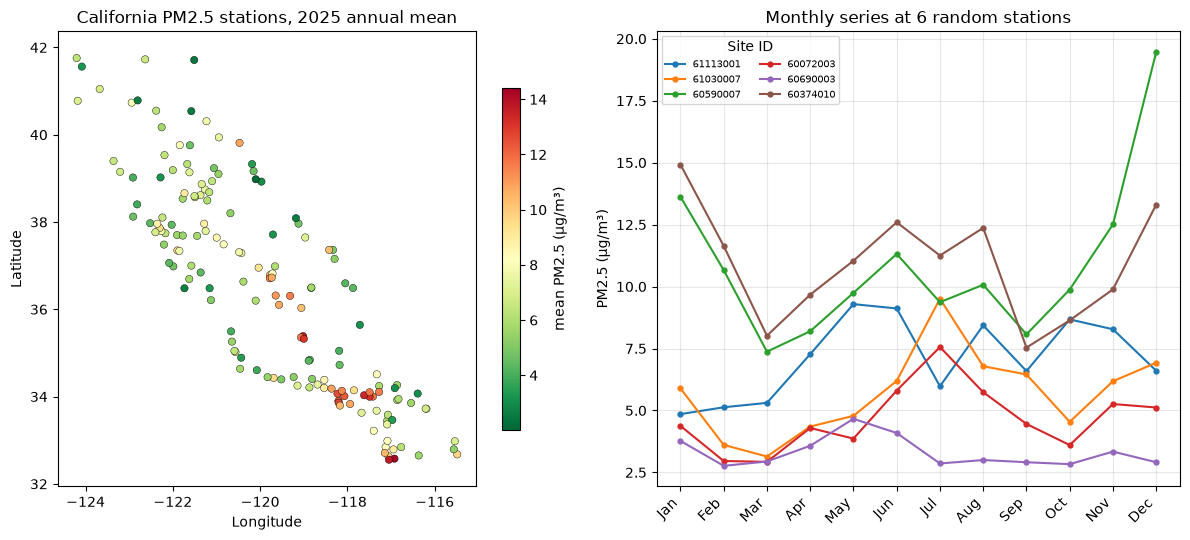

In [4]:
mean_pm = panel.groupby("site_id")["pm25"].mean().rename("mean_pm25")
site_meta = (
    panel[["site_id", "x", "y", "lat", "lon"]]
    .drop_duplicates("site_id")
    .merge(mean_pm, on="site_id")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

sc = axes[0].scatter(
    site_meta["lon"], site_meta["lat"], c=site_meta["mean_pm25"],
    cmap="RdYlGn_r", s=28, edgecolor="k", linewidth=0.3,
)
plt.colorbar(sc, ax=axes[0], label="mean PM2.5 (µg/m³)", shrink=0.75)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("California PM2.5 stations, 2025 annual mean")
axes[0].set_aspect("equal", adjustable="datalim")

for site in panel["site_id"].drop_duplicates().sample(6, random_state=0):
    sub = panel[panel["site_id"] == site].sort_values("month")
    axes[1].plot(sub["month"], sub["pm25"], marker="o", ms=3.5, label=str(int(site)))
axes[1].set_xticks(range(12), MONTH_NAMES, rotation=45, ha="right")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("Monthly series at 6 random stations")
axes[1].legend(fontsize=7, ncol=2, title="Site ID")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Annual-mean PM2.5 is highest in the Central Valley and the South Coast and
lowest along the north coast and Sierra. The six example series show a shared
seasonal pattern (higher in winter) plus station-to-station differences — the
two ingredients a space-time covariance has to capture.



***
## 6. Hold-Out Station Split

To test genuine spatial-temporal *extrapolation* (not just interpolating a
missing month at a known site), we hold out **25 stations with complete
12-month coverage** entirely. Every month at those sites is predicted from
neighbors among the remaining 138 stations. The 7 stations with partial-year
coverage stay in the training set: `STKriging` does not need a complete grid.


Train : 138 stations, 1635 site-months
Test  : 25 stations (held out), 300 site-months


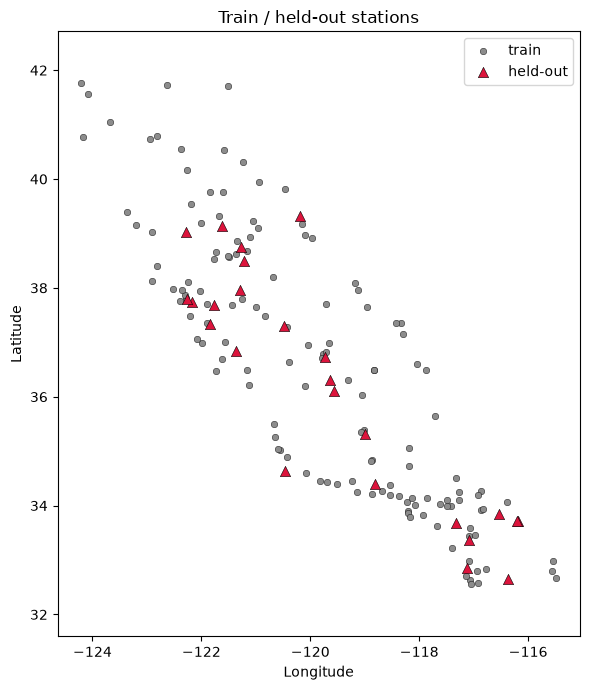

In [5]:
test_sites = rng.choice(complete_sites, size=25, replace=False)
is_test = panel["site_id"].isin(test_sites)
train = panel.loc[~is_test].reset_index(drop=True)
test = panel.loc[is_test].reset_index(drop=True)

print(f"Train : {train['site_id'].nunique()} stations, {len(train)} site-months")
print(f"Test  : {test['site_id'].nunique()} stations (held out), {len(test)} site-months")

fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(train.drop_duplicates("site_id")["lon"],
           train.drop_duplicates("site_id")["lat"],
           s=22, c="0.55", edgecolor="k", linewidth=0.3, label="train")
ax.scatter(test.drop_duplicates("site_id")["lon"],
           test.drop_duplicates("site_id")["lat"],
           s=55, c="crimson", edgecolor="k", linewidth=0.4, marker="^", label="held-out")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Train / held-out stations")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()


***
## 7. Empirical Space-Time Variogram

`empirical_st_variogram` needs a complete station $\times$ month matrix, so this
step uses only **training stations with all 12 months**. Temporal lags are the
integer month differences $0, 1, \ldots, 11$; spatial lags are equal-width
bins out to half the maximum pairwise distance.


In [6]:
train_complete = train[train["site_id"].isin(complete_sites)]
train_wide = (
    train_complete.pivot(index="site_id", columns="month", values="pm25").sort_index()
)
train_coords = (
    train_complete[["site_id", "x", "y"]].drop_duplicates("site_id")
    .set_index("site_id").loc[train_wide.index][["x", "y"]].to_numpy()
)
months = np.sort(train_complete["month"].unique()).astype(float)

emp = empirical_st_variogram(
    train_coords, months, train_wide.to_numpy(), n_space_bins=10,
)
print(f"{len(emp['dist'])} (space-bin, time-lag) cells from {emp['np'].sum():.0f} pairs")
print(f"spatial lags : {np.unique(emp['dist']).size} bins, "
      f"0 – {emp['dist'].max()/1000:.0f} km")
print(f"temporal lags: {np.unique(emp['timelag']).size} month steps")

120 (space-bin, time-lag) cells from 1009158 pairs
spatial lags : 10 bins, 0 – 603 km
temporal lags: 12 month steps


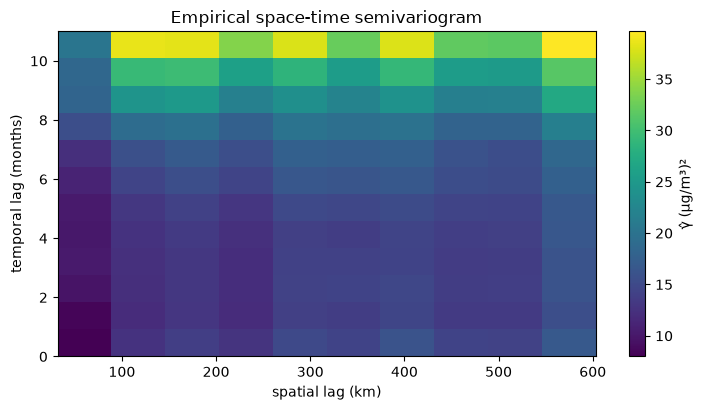

In [7]:
lag_vals = np.sort(np.unique(emp["timelag"]))
dist_vals = np.sort(np.unique(emp["dist"]))
G = np.full((len(lag_vals), len(dist_vals)), np.nan)
for hs, ht, g in zip(emp["dist"], emp["timelag"], emp["gamma"]):
    i = int(np.where(lag_vals == ht)[0][0])
    j = int(np.where(dist_vals == hs)[0][0])
    G[i, j] = g

fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(
    G, origin="lower", aspect="auto", cmap="viridis",
    extent=[dist_vals.min()/1000, dist_vals.max()/1000,
            lag_vals.min(), lag_vals.max()],
)
plt.colorbar(im, ax=ax, label="γ̂ (µg/m³)²")
ax.set_xlabel("spatial lag (km)")
ax.set_ylabel("temporal lag (months)")
ax.set_title("Empirical space-time semivariogram")
plt.tight_layout()
plt.show()


Semivariance grows with both spatial distance and temporal lag: nearby
stations in the same month are more alike than distant stations many months
apart. That joint structure is what the metric model will compress into a
single distance $h_{st}$.



***
## 8. Fit the Metric ST Model

`fit_metric_st_variogram` builds a metric `vgm_st` model with data-driven
starting values (nugget, partial sill, range, `stAni`) and fits it to the
empirical cells by weighted least squares.


In [8]:
fitted_model = fit_metric_st_variogram(emp)
nugget, sill, prange = joint_nugget_sill_range(fitted_model["joint"])
st_ani = fitted_model["stAni"]

print(f"stModel : {fitted_model['stModel']}")
print(f"nugget  : {nugget:.3f} (µg/m³)²")
print(f"psill   : {sill:.3f} (µg/m³)²")
print(f"range   : {prange/1000:.1f} km")
print(f"stAni   : {st_ani/1000:.1f} km / month")
print(f"MSE     : {fitted_model['MSE']:.4f}")
print(f"\nOne month of time is equivalent to {st_ani/1000:.0f} km of space "
      f"under the fitted anisotropy.")

stModel : metric
nugget  : 0.000 (µg/m³)²
psill   : 23.031 (µg/m³)²
range   : 374.5 km
stAni   : 102.1 km / month
MSE     : 28.4358

One month of time is equivalent to 102 km of space under the fitted anisotropy.


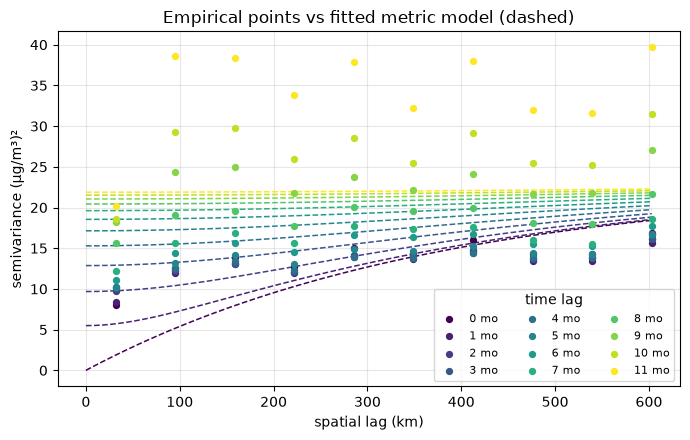

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
show_lags = sorted(set(emp["timelag"]))
colors = plt.cm.viridis(np.linspace(0, 1, len(show_lags)))
h = np.linspace(0, emp["dist"].max(), 120)
for lag, c in zip(show_lags, colors):
    m = emp["timelag"] == lag
    ax.scatter(emp["dist"][m] / 1000, emp["gamma"][m], s=18, color=c,
               label=f"{lag:.0f} mo", zorder=3)
    hh = np.sqrt(h ** 2 + (st_ani * lag) ** 2)
    ax.plot(h / 1000, variogram_line(fitted_model["joint"], hh, covariance=False),
            "--", color=c, linewidth=1.1)
ax.set_xlabel("spatial lag (km)")
ax.set_ylabel("semivariance (µg/m³)²")
ax.set_title("Empirical points vs fitted metric model (dashed)")
ax.legend(fontsize=8, ncol=3, title="time lag")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Each color is one temporal lag. The metric model raises the whole curve as
$h_t$ grows (because $h_{st}$ includes $a h_t$) while keeping a single
nugget–sill–range shape. A good fit means the dashed lines track the points
across lags, not just at $h_t = 0$.



***
## 9. Fit STKriging

`STKriging.fit` stores **all** 138 training stations (complete and
partial-year). No complete grid is required here — only the earlier variogram
estimation step needed one. Predictions will use `nmax=20` nearest
space-time neighbors.


In [10]:
stk = STKriging(fitted_model, use_gpu=USE_GPU).fit(
    coords=train[["x", "y"]].to_numpy(),
    times=train["month"].to_numpy(float),
    values=train["pm25"].to_numpy(),
    ids=train["site_id"].to_numpy(),
)
print(f"Fitted STKriging on {len(train)} observations "
      f"from {train['site_id'].nunique()} stations")


Fitted STKriging on 1635 observations from 138 stations



***
## 10. Validate on Held-Out Stations

Predict every station-month of the 25 held-out stations from their nearest
training neighbors, and compare against a **naive baseline**: the overall
training-mean PM2.5, which uses no spatial or temporal information.


In [11]:
zhat, sig = stk.predict(
    test[["x", "y"]].to_numpy(), test["month"].to_numpy(float), nmax=20,
)
test = test.assign(zhat=zhat, sig=sig)

rmse = float(np.sqrt(mean_squared_error(test["pm25"], test["zhat"])))
mae = float(mean_absolute_error(test["pm25"], test["zhat"]))
r2 = float(r2_score(test["pm25"], test["zhat"]))
me = float((test["pm25"] - test["zhat"]).mean())
baseline_rmse = float(np.sqrt(mean_squared_error(
    test["pm25"], np.full(len(test), train["pm25"].mean()),
)))

metrics = pd.DataFrame({
    "metric": ["RMSE (µg/m³)", "MAE (µg/m³)", "Mean error (µg/m³)",
               "R²", "Naive-mean RMSE", "Mean kriging SD"],
    "value": [rmse, mae, me, r2, baseline_rmse, float(test["sig"].mean())],
})
metrics

,metric,value
0,RMSE (µg/m³),2.242910
1,MAE (µg/m³),1.732865
2,Mean error (µg/m³),0.176228
3,R²,0.576986
4,Naive-mean RMSE,3.460786
5,Mean kriging SD,1.179734


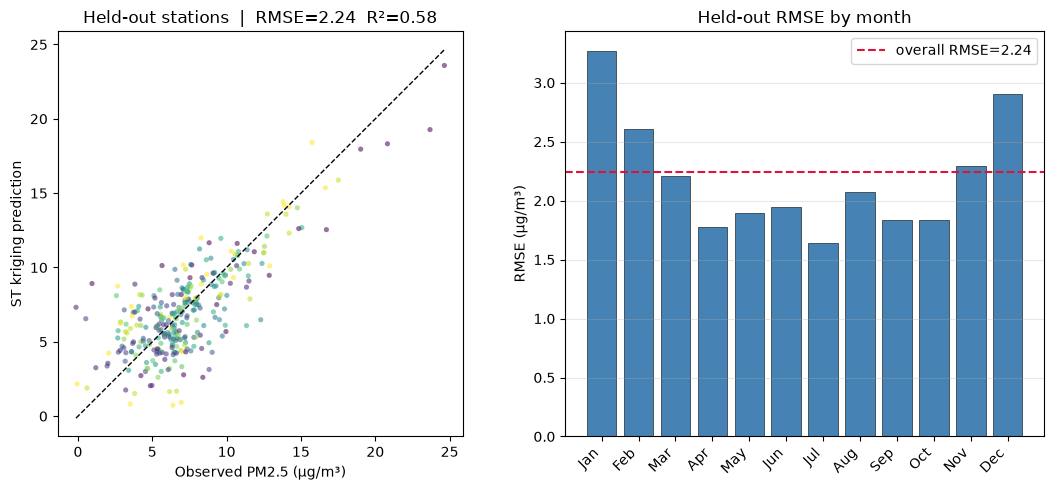

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

lims = [
    min(test["pm25"].min(), test["zhat"].min()),
    max(test["pm25"].max(), test["zhat"].max()),
]
axes[0].scatter(test["pm25"], test["zhat"], s=14, alpha=0.55,
                c=test["month"], cmap="viridis", edgecolor="none")
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("Observed PM2.5 (µg/m³)")
axes[0].set_ylabel("ST kriging prediction")
axes[0].set_title(f"Held-out stations  |  RMSE={rmse:.2f}  R²={r2:.2f}")
axes[0].set_aspect("equal", adjustable="box")

by_month = np.sqrt(
    test.groupby("month").apply(
        lambda g: ((g["pm25"] - g["zhat"]) ** 2).mean(), include_groups=False,
    )
)
axes[1].bar(by_month.index, by_month.values, color="steelblue", edgecolor="k", linewidth=0.4)
axes[1].axhline(rmse, color="crimson", linestyle="--", label=f"overall RMSE={rmse:.2f}")
axes[1].set_xticks(range(12), MONTH_NAMES, rotation=45, ha="right")
axes[1].set_ylabel("RMSE (µg/m³)")
axes[1].set_title("Held-out RMSE by month")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

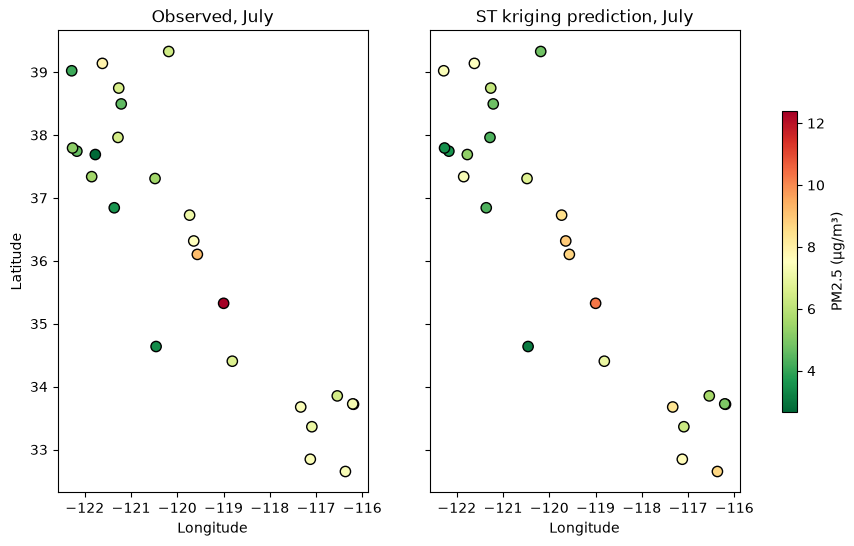

In [13]:
snap = test[test["month"] == 6]  # July
vmin, vmax = snap[["pm25", "zhat"]].min().min(), snap[["pm25", "zhat"]].max().max()
fig, ax = plt.subplots(1, 2, figsize=(11, 6), sharex=True, sharey=True)
s0 = ax[0].scatter(snap["lon"], snap["lat"], c=snap["pm25"], vmin=vmin, vmax=vmax,
                   cmap="RdYlGn_r", s=55, edgecolor="k")
ax[0].set_title("Observed, July")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
s1 = ax[1].scatter(snap["lon"], snap["lat"], c=snap["zhat"], vmin=vmin, vmax=vmax,
                   cmap="RdYlGn_r", s=55, edgecolor="k")
ax[1].set_title("ST kriging prediction, July")
ax[1].set_xlabel("Longitude")
fig.colorbar(s1, ax=ax, shrink=0.65, label="PM2.5 (µg/m³)")
plt.show()


If RMSE is well below the naive-mean baseline, the space-time covariance is
doing real work: nearby stations and nearby months are informing the
prediction. Residual RMSE that varies by month usually tracks the seasonal
amplitude of PM2.5 (winter is harder).



***
## 11. Leave-One-Out Check

`predict_id` re-predicts one of the *known* training observations after
excluding it from its own neighbor search. Ten random training station-months:


In [14]:
sample = train.sample(10, random_state=0)
loo = pd.DataFrame([
    stk.predict_id(row["site_id"], row["month"], nmax=20)
    for _, row in sample.iterrows()
])
loo["observed"] = sample["pm25"].to_numpy()
loo["abs_err"] = (loo["zhat"] - loo["observed"]).abs()
print(f"mean |error| = {loo['abs_err'].mean():.2f} µg/m³")
loo[["id", "time", "observed", "zhat", "sig", "abs_err"]].rename(
    columns={"id": "site_id", "time": "month"}
)

mean |error| = 1.45 µg/m³


,site_id,month,observed,zhat,sig,abs_err
0,60090001.0,4.0,4.809677,4.608570,1.881361,0.201107
1,60811001.0,6.0,2.873333,4.556653,1.363031,1.683320
2,60731017.0,6.0,7.838710,6.863764,1.297365,0.974946
3,60792020.0,10.0,5.220000,4.430840,1.240101,0.789160
4,60731008.0,9.0,8.145161,7.016091,1.543689,1.129070
5,60670015.0,3.0,5.513333,5.259989,0.554124,0.253344
6,60650016.0,10.0,4.113333,5.117903,1.091862,1.004570
7,60374008.0,9.0,12.073770,9.938383,0.600662,2.135387
8,60631010.0,9.0,9.625714,6.545034,1.801768,3.080680
9,60530008.0,7.0,6.254839,3.032157,1.598713,3.222682



***
## 12. Forecast One Month Ahead

Predicting month index 12 (one month past December 2025) is pure **temporal
extrapolation** at known station coordinates, using only the fitted
space-time covariance — no future observations.


In [15]:
demo_sites = train["site_id"].drop_duplicates().sample(3, random_state=0).to_numpy()
demo_coords = (
    train[["site_id", "x", "y"]].drop_duplicates("site_id")
    .set_index("site_id").loc[demo_sites][["x", "y"]].to_numpy()
)
fzhat, fsig = stk.predict(demo_coords, np.full(3, 12.0), nmax=20)

rows = []
for site, zh, sg in zip(demo_sites, fzhat, fsig):
    hist = train.loc[train["site_id"] == site].sort_values("month")
    rows.append({
        "site_id": int(site),
        "Dec 2025 observed": hist.iloc[-1]["pm25"],
        "Jan 2026 forecast": zh,
        "kriging SD": sg,
    })
pd.DataFrame(rows)

,site_id,Dec 2025 observed,Jan 2026 forecast,kriging SD
0,60130002,7.029032,9.577247,2.869686
1,60612003,10.580645,7.289336,2.843275
2,60271003,2.682927,3.949907,2.882661



The forecast is a kriging interpolator in $(x, y, a t)$ space, not a dynamical
air-quality model. Treat the kriging standard error as a lower bound on
uncertainty: it captures spatial-temporal sampling density, not process
misspecification (fires, stagnation events, and so on).



***
## 13. Map PM2.5 on a California Grid

The usual end product is a continuous map. We extract California's boundary
from `data/US_STATE.shp`, build a 5 km $\times$ 5 km grid clipped to it
(`make_prediction_grid`), and predict at every cell for each of the 12 months.

For a production map we **refit `STKriging` on the full 163-station panel**
(rather than the train/test split), reusing the metric variogram fitted above.
Ordinary kriging has no positivity constraint, so a handful of cells far from
any station can come out slightly negative; those are clipped to 0.


In [16]:
ca_states = gpd.read_file("../data/US_STATE.shp")
ca = ca_states[ca_states["STATE"] == "California"].to_crs("EPSG:3310")
grid = make_prediction_grid(ca, cell_size=5000.0)
print(f"California boundary : {len(ca)} polygon feature(s), EPSG:3310")
print(f"Prediction grid     : {len(grid):,} cells at 5 km spacing")

California boundary : 1 polygon feature(s), EPSG:3310
Prediction grid     : 16,397 cells at 5 km spacing


In [17]:
stk_full = STKriging(fitted_model, use_gpu=USE_GPU).fit(
    coords=panel[["x", "y"]].to_numpy(),
    times=panel["month"].to_numpy(float),
    values=panel["pm25"].to_numpy(),
    ids=panel["site_id"].to_numpy(),
)

grid_xy = grid[["x", "y"]].to_numpy()
grid_rows = []
n_clipped_total = 0
for m in range(12):
    zh, sg = stk_full.predict(grid_xy, np.full(len(grid_xy), float(m)), nmax=20)
    n_clipped_total += int(np.sum(zh < 0))
    zh = np.clip(zh, 0.0, None)
    grid_rows.append(pd.DataFrame({
        "x": grid_xy[:, 0], "y": grid_xy[:, 1],
        "month": m, "month_name": MONTH_NAMES[m],
        "pm25_pred": zh, "pm25_sd": sg,
    }))
grid_pred = pd.concat(grid_rows, ignore_index=True)

print(f"{len(grid_pred):,} grid-month predictions")
print(f"{n_clipped_total} slightly-negative cells clipped to 0 "
      f"({100 * n_clipped_total / len(grid_pred):.2f}%)")
grid_pred.to_csv("../data/CA_pm25_grid_predictions.csv", index=False)
grid_pred.groupby("month_name")["pm25_pred"].agg(["mean", "min", "max"]).loc[MONTH_NAMES]

196,764 grid-month predictions
220 slightly-negative cells clipped to 0 (0.11%)


,mean,min,max
month_name,,,
Jan,7.709564,0.000000,25.279088
Feb,5.137448,0.000000,18.226996
Mar,4.390523,0.000000,10.924086
Apr,5.201641,1.926392,11.244082
May,5.663966,2.098568,13.997873
Jun,6.266400,1.012398,15.006396
Jul,6.009915,0.000000,13.116197
Aug,6.195421,1.639260,15.310637
Sep,6.536328,2.397926,38.479394


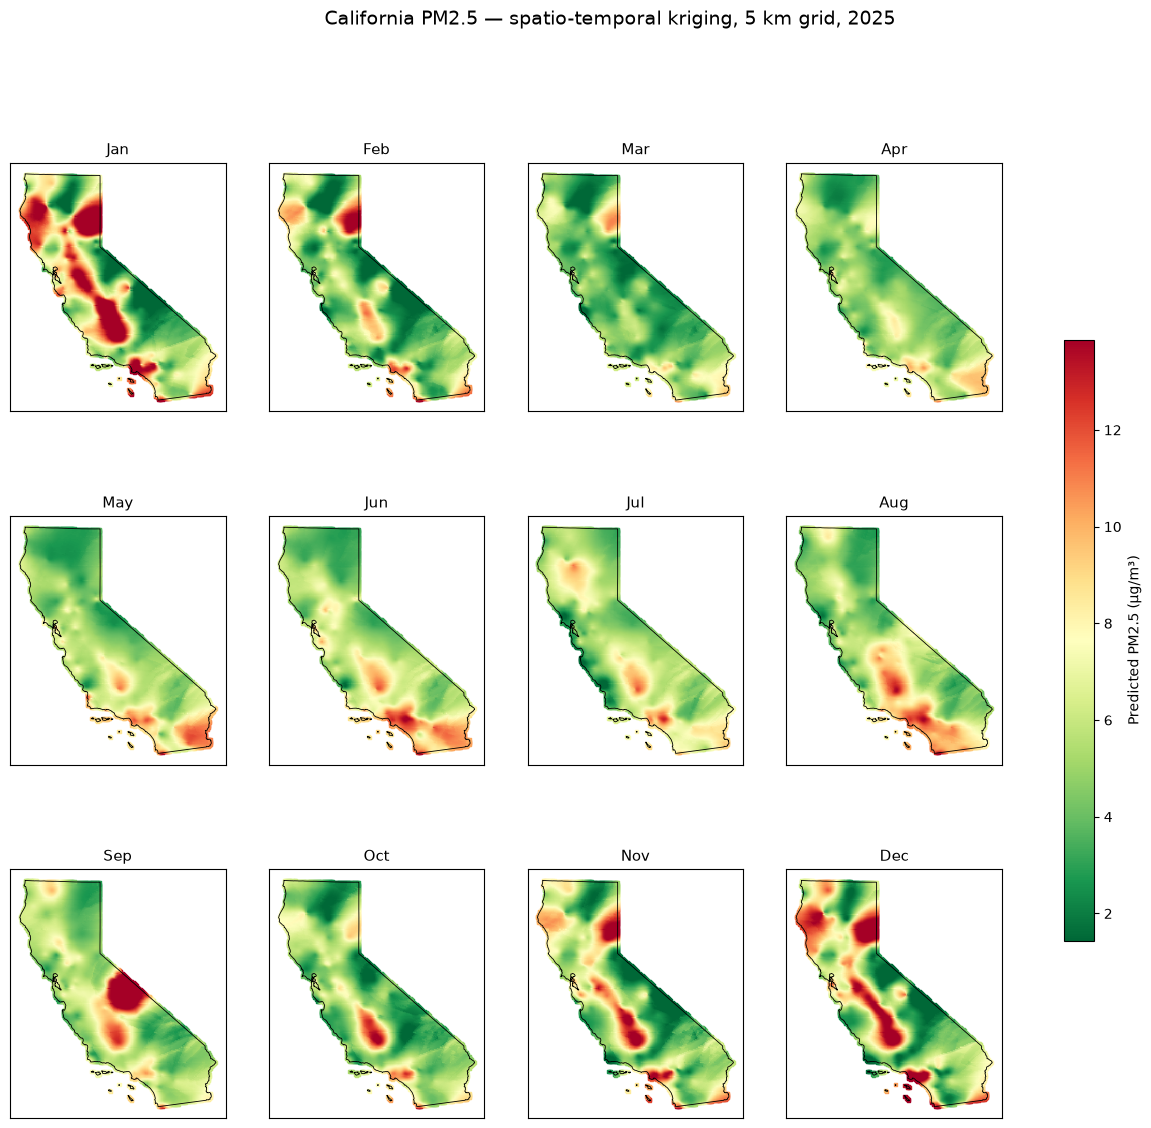

In [18]:
vmin, vmax = grid_pred["pm25_pred"].quantile(0.02), grid_pred["pm25_pred"].quantile(0.98)
fig, axes = plt.subplots(3, 4, figsize=(16, 13), sharex=True, sharey=True)
for m, ax in enumerate(axes.ravel()):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(sub["x"], sub["y"], c=sub["pm25_pred"], cmap="RdYlGn_r",
                    vmin=vmin, vmax=vmax, s=5, marker="s")
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(MONTH_NAMES[m], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(sc, ax=axes, shrink=0.6, label="Predicted PM2.5 (µg/m³)")
fig.suptitle("California PM2.5 — spatio-temporal kriging, 5 km grid, 2025", fontsize=14)
plt.show()

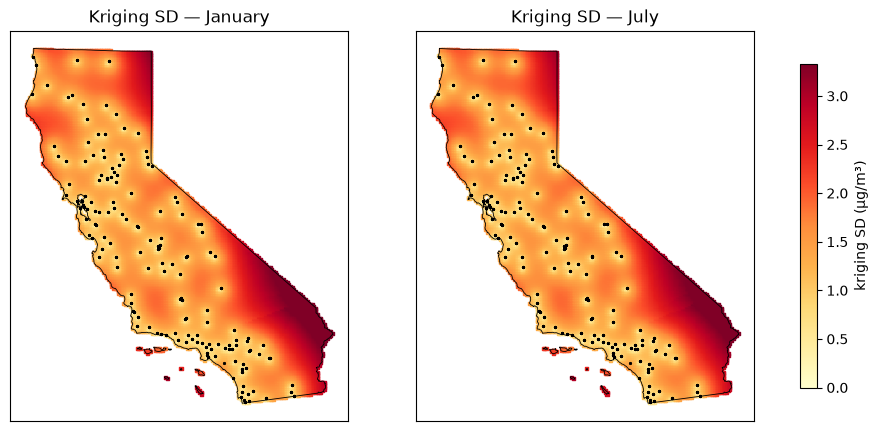

In [19]:
# Kriging standard error for January and July, plus stations
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
sd_max = grid_pred["pm25_sd"].quantile(0.98)
for ax, m, title in zip(axes, [0, 6], ["January", "July"]):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(sub["x"], sub["y"], c=sub["pm25_sd"], cmap="YlOrRd",
                    vmin=0, vmax=sd_max, s=5, marker="s")
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.scatter(panel["x"], panel["y"], s=6, c="k", marker=".", alpha=0.5)
    ax.set_title(f"Kriging SD — {title}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(sc, ax=axes, shrink=0.7, label="kriging SD (µg/m³)")
plt.show()


The monthly maps recover the well-known California pattern: winter peaks in
the Central Valley, cleaner conditions along the coast, and a summer contrast
driven by wildfire and photochemistry. The standard-error maps are high where
stations are sparse (eastern deserts, far north) and low in the South Coast
and Central Valley networks — a map of **how well the data constrain the
estimate**, not of PM2.5 itself.


***
## 14. CPU vs GPU ST Kriging Timing

The ~1,600-row CA station panel is too small for a GPU comparison: the batched
ST-kriging solve is a stack of tiny $k\times k$ systems, and host→device copies
dominate. Here we **simulate a CA-like monthly PM2.5 panel** with Sequential
Gaussian Simulation (`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$,
then time **k-nearest-neighbor** ST kriging (`nmax=20`) on **CPU**
(`use_gpu=False`) versus **GPU** (`use_gpu=True`).

Simulation recipe (conditioned on the real 163 stations):

1. Draw $n_{\mathrm{sites}} = 700$ random locations in the California bounding box.
2. Simulate $\log(\mathrm{PM2.5})$ with `sgsim` (exponential variogram, practical range 250 km, conditioned on station-mean PM2.5 from `data/CA_pm25_2025.csv`) and back-transform with $\exp(\cdot)$.
3. Expand each site across 12 months using the observed statewide monthly relative seasonality, giving $n_{\mathrm{train}} = 8{,}400$.
4. Draw a separate prediction set of $(x, y, t)$ locations (no values needed — kriging only needs coordinates plus the training data).

Unlike global ordinary kriging, the GPU work scales with **$n_{\mathrm{pred}}$** (one stacked solve of shape `(n_pred, nmax, nmax)` per `predict` call), not $n_{\mathrm{train}}^3$. Training size is therefore held at 8{,}400 and we vary $n_{\mathrm{pred}}$. The metric ST model is the **fitted CA model from §8**, so fitting $\gamma$ is **not** in the times. Each timing is `fit` plus `predict(..., nmax=20, compute_var=True)`.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped.


Simulating 700 CA-like PM2.5 sites with sgsim, then 12 months
  conditioning : 163 station means from data/CA_pm25_2025.csv
  vario        : azimuth=0, nugget=0.009, range=250 km, exponential, log(PM2.5)
  sgsim wall   : 5.1 s  (not included in STKriging times)
  simulated PM2.5 : [1.07, 25.30] µg/m³  (CA observed [-0.50, 39.05])

GPU usable : True
Repeats    : 3  (median wall time of STKriging fit + predict, k-NN)
n_train    : 8400  (sgsim CA-like PM2.5 panel, 700 sites × 12 months)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations/months in the CA bbox)
neighbors  : nmax=20; metric ST model from §8 (CA PM2.5 panel)

         dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
CA PM2.5 (sgsim)     8400     500      41.2      31.9   1.29×   True
CA PM2.5 (sgsim)     8400    1000      66.3      25.5   2.60×   True
CA PM2.5 (sgsim)     8400    2000      89.7      28.3   3.17×   True
CA PM2.5 (sgsim)     8400    4000     168.8      32.3   5.23×   True
CA PM2.5 (sgsim) 

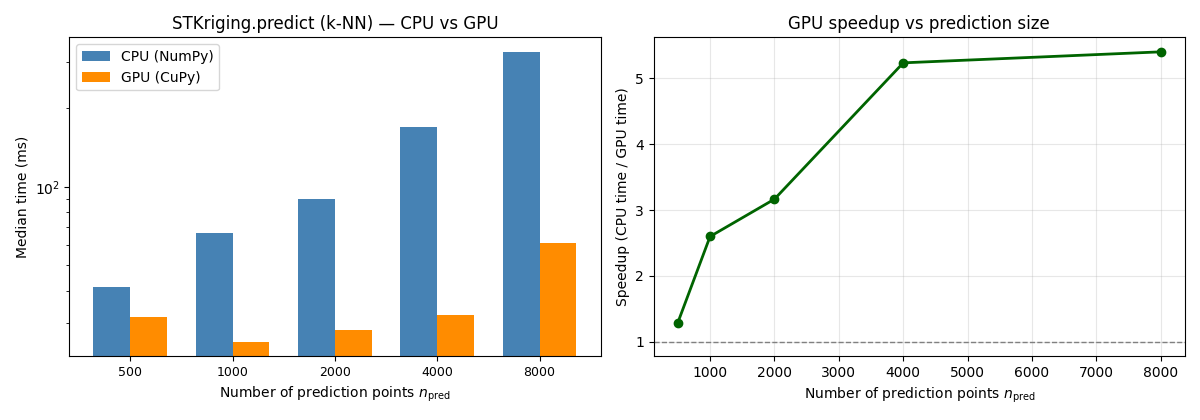

In [20]:
import time

N_REPEATS = 3
N_SITES = 700
N_MONTHS = 12
N_TRAIN = N_SITES * N_MONTHS
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
NMAX = 20
rng_sim = np.random.default_rng(42)

site = panel.groupby("site_id")[["x", "y", "pm25"]].mean().reset_index()
month_factor = panel.groupby("month")["pm25"].mean()
month_factor = (month_factor / month_factor.mean()).to_numpy()

pad = 15_000.0
xmin, xmax = float(panel["x"].min()) - pad, float(panel["x"].max()) + pad
ymin, ymax = float(panel["y"].min()) - pad, float(panel["y"].max()) + pad
xy_sites = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_SITES, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))
t_pred_all = rng_sim.integers(0, N_MONTHS, size=N_PRED_MAX).astype(float)

df_cond = pd.DataFrame({
    "x": site["x"].to_numpy(),
    "y": site["y"].to_numpy(),
    "log_pm25": np.log(np.maximum(site["pm25"].to_numpy(), 0.1)),
})
log_var = float(np.var(df_cond["log_pm25"]))
vario_sgs = [0, 0.05 * log_var, 250_000.0, 250_000.0, log_var, "exponential"]

print(f"Simulating {N_SITES:,} CA-like PM2.5 sites with sgsim, then {N_MONTHS} months")
print(f"  conditioning : {len(site)} station means from data/CA_pm25_2025.csv")
print(f"  vario        : azimuth=0, nugget={vario_sgs[1]:.3f}, range=250 km, exponential, log(PM2.5)")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_sites, df_cond, "x", "y", "log_pm25",
    num_points=12, vario=vario_sgs, radius=500_000.0,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
spatial = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in STKriging times)")

values_grid = spatial[:, None] * month_factor[None, :]
coords_train = np.repeat(xy_sites, N_MONTHS, axis=0)
times_train = np.tile(np.arange(N_MONTHS, dtype=float), N_SITES)
values_train = values_grid.ravel()
print(f"  simulated PM2.5 : [{values_train.min():.2f}, {values_train.max():.2f}] µg/m³"
      f"  (CA observed [{panel['pm25'].min():.2f}, {panel['pm25'].max():.2f}])")
print()


def _time_stk(xy, t, z, xy_pred, t_pred, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of STKriging.fit + predict (k-NN nmax)."""
    def once(xy_tr, t_tr, z_tr, xy_pr, t_pr):
        stk = STKriging(fitted_model, use_gpu=use_gpu).fit(xy_tr, t_tr, z_tr)
        return stk.predict(xy_pr, t_pr, nmax=NMAX, compute_var=True, progress=False)

    if warmup:
        k_tr = min(80, len(xy))
        k_pr = min(40, len(xy_pred))
        once(xy[:k_tr], t[:k_tr], z[:k_tr], xy_pred[:k_pr], t_pred[:k_pr])
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last = once(xy, t, z, xy_pred, t_pred)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of STKriging fit + predict, k-NN)")
print(f"n_train    : {N_TRAIN}  (sgsim CA-like PM2.5 panel, {N_SITES} sites × {N_MONTHS} months)")
print(f"n_pred     : {PRED_SIZES}  (random locations/months in the CA bbox)")
print(f"neighbors  : nmax={NMAX}; metric ST model from §8 (CA PM2.5 panel)")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    t_pr = t_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_stk(
        coords_train, times_train, values_train, xy_pr, t_pr, use_gpu=False,
    )
    row = {
        "dataset": "CA PM2.5 (sgsim)",
        "n_train": N_TRAIN,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_stk(
            coords_train, times_train, values_train, xy_pr, t_pr, use_gpu=True,
        )
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        zc, sc = pred_cpu
        zg, sg = pred_gpu
        row["match"] = bool(
            np.allclose(zc, zg, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(sc, sg, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("STKriging.predict (k-NN) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging standard errors from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, k, k)$ space-time kriging solve (covariance + `xp.linalg.solve`), not from SGS (simulation is CPU sequential and is excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` with a finite `nmax` so the same cells run on a laptop CPU or a CUDA workstation without edits.



***
## 15. Summary and Conclusions

This tutorial walked through a complete **spatio-temporal ordinary kriging**
workflow for California monthly PM2.5.

### What we did

1. Aggregated daily station readings to a monthly panel and projected locations to EPSG:3310.
2. Held out **25 complete stations** so validation is true spatial-temporal extrapolation.
3. Estimated the empirical space-time semivariogram on complete training stations and fitted a **metric** model ($\gamma(h_{st})$ with $h_{st}=\sqrt{h_s^2+(a h_t)^2}$).
4. Fitted `STKriging` on all training station-months and predicted with a local neighborhood (`nmax=20`).
5. Reported RMSE, MAE, $R^2$, and a naive-mean baseline on the held-out stations.
6. Mapped predicted PM2.5 and kriging standard error on a 5 km California grid for all 12 months.
7. Timed k-NN `STKriging.predict` on CPU vs GPU using an SGS-simulated CA-like panel ($n_{\mathrm{train}}=8{,}400$).

### Practical takeaways

- **Variogram estimation needs a complete panel**; kriging does not. Drop incomplete stations only for $\hat\gamma$, then use every observation as a neighbor.
- Hold out **whole stations**, not random station-months, if you care about interpolating at unsampled locations.
- The metric model is a robust default. If space and time clearly have different ranges or sills, try `separable` or `sumMetric` via `vgm_st` / `fit_st_variogram`.
- Local kriging (`nmax`) is what makes statewide mapping practical. Global ST kriging on $\sim 2{,}000$ observations is already slow; on a 16k-cell grid it is not feasible.
- Ordinary kriging can produce slightly negative concentrations far from data. Clip to the physical range *after* kriging, and treat those cells as poorly supported (check $\sigma$).
- **CPU / GPU.** k-NN ST kriging (`nmax` finite, `use_gpu=USE_GPU`) batches one `(n_pred, nmax, nmax)` solve. GPU work scales with $n_{\mathrm{pred}}$, not $n_{\mathrm{train}}^3$. The 163-station CA panel is too small to show that; §14 uses SGS so $n > 5{,}000$.

### Next steps

- 3-D kriging (`Tutorial/09_kriging_3d.ipynb`) when the third coordinate is depth, not time
- Spatio-temporal Poisson kriging (`STPoissonKriging`) for areal disease or mortality *rates*
- Indicator kriging if you need exceedance probabilities without a Gaussian assumption



***
## 16. Resources

### Textbooks and software papers

| Reference | Notes |
|-----------|-------|
| Pebesma, E. (2012). spacetime: Spatio-Temporal Data in R. *Journal of Statistical Software*, 51(7). | Source of gstat's `krigeST` / `vgmST`; this module is a Python port |
| Cressie, N. & Wikle, C.K. (2011). *Statistics for Spatio-Temporal Data*. Wiley. | Broader ST random-field theory |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Kriging system and variance |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford. | Ordinary kriging practice |

### In this library

| Object | Role |
|--------|------|
| `pygstat.STKriging` | Fit / predict space-time ordinary kriging (`use_gpu`) |
| `pygstat.load_ca_pm25_panel` | Daily CA PM2.5 CSV → monthly panel in EPSG:3310 |
| `pygstat.make_prediction_grid` | Regular grid clipped to a polygon boundary |
| `empirical_st_variogram` | Matheron estimator on a complete site $\times$ time matrix |
| `fit_metric_st_variogram` | Fit the metric ST model |
| `pygstat.krige_st.krige_st` | Lower-level gstat-style ST kriging |
| `pygstat.sgsim` | Sequential Gaussian Simulation (used in §14 to build $n>5{,}000$ training data) |
| `STPoissonKriging` | Space-time Poisson kriging for areal rates |
| Tutorial 04 | Spatial ordinary kriging (no time dimension) |
| Tutorial 09 | 3-D kriging (`kt3d`) |
